# 02 — Why DQN self-play doesn't reach Nash (exactly, on Leduc)

Plain DQN self-play violates the stationarity Q-learning needs: the opponent moves while you learn. This notebook makes that **exact** on Leduc Hold'em using the committed exploitability metric (`src/leduc_eval.py`), reproduced from `results/exploitability.json`.

*Exploitability (NashConv)* = how much a best response beats the strategy; **0 = exact Nash**.

In [1]:
import os, sys, json
# Walk up to the repo root (works whether the kernel cwd is notebooks/ or root).
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, "results"))
          and os.path.isdir(os.path.join(ROOT, "src"))) \
        and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import Image, display

def load(name):
    with open(os.path.join(ROOT, "results", name)) as f:
        return json.load(f)

def fig(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("repo root resolved:", os.path.basename(ROOT))

repo root resolved: poker-simulation


## Three regimes: CFR average, CFR last-iterate, and an actual Q-learner

CFR's **time-average** strategy converges toward Nash (exploitability → 0). The greedy **CFR last-iterate** (its current regret-matching strategy, no averaging) stays exploitable. And — measured **directly**, not by analogy — an **independent tabular Q-learning self-play** (an actual DQN-regime learner: greedy off-policy TD, ε-greedy, no averaging; `src/leduc_q.py`) oscillates and never reaches Nash. Three points, one conclusion: averaging reaches equilibrium, greedy value-learning does not.

In [2]:
e = load("exploitability.json")
curve = e["curve"]
a0, aN = curve[0]["avg_exploitability"], curve[-1]["avg_exploitability"]
lN = curve[-1]["last_iterate_exploitability"]
print(f"iterations: {curve[0]['iters']} -> {curve[-1]['iters']}")
print(f"CFR time-AVERAGE exploitability: {a0:.3f} -> {aN:.4f}   (-> Nash)")
print(f"CFR greedy LAST-ITERATE        : {lN:.3f}              (stays exploitable)")
q, qr = e.get("q_last_iterate_mean"), e.get("q_last_iterate_range")
if q is not None:
    print(f"Q-learning self-play last-iter : oscillates ~{q:.2f}, range "
          f"[{qr[0]:.2f}, {qr[1]:.2f}]   (independent DQN-regime learner, never near Nash)")
if e.get("uniform_exploitability") is not None:
    print(f"uniform-random baseline        : {e['uniform_exploitability']:.3f}")

iterations: 10 -> 10000
CFR time-AVERAGE exploitability: 0.695 -> 0.0090   (-> Nash)
CFR greedy LAST-ITERATE        : 2.200              (stays exploitable)
Q-learning self-play last-iter : oscillates ~3.40, range [1.70, 5.53]   (independent DQN-regime learner, never near Nash)
uniform-random baseline        : 4.747


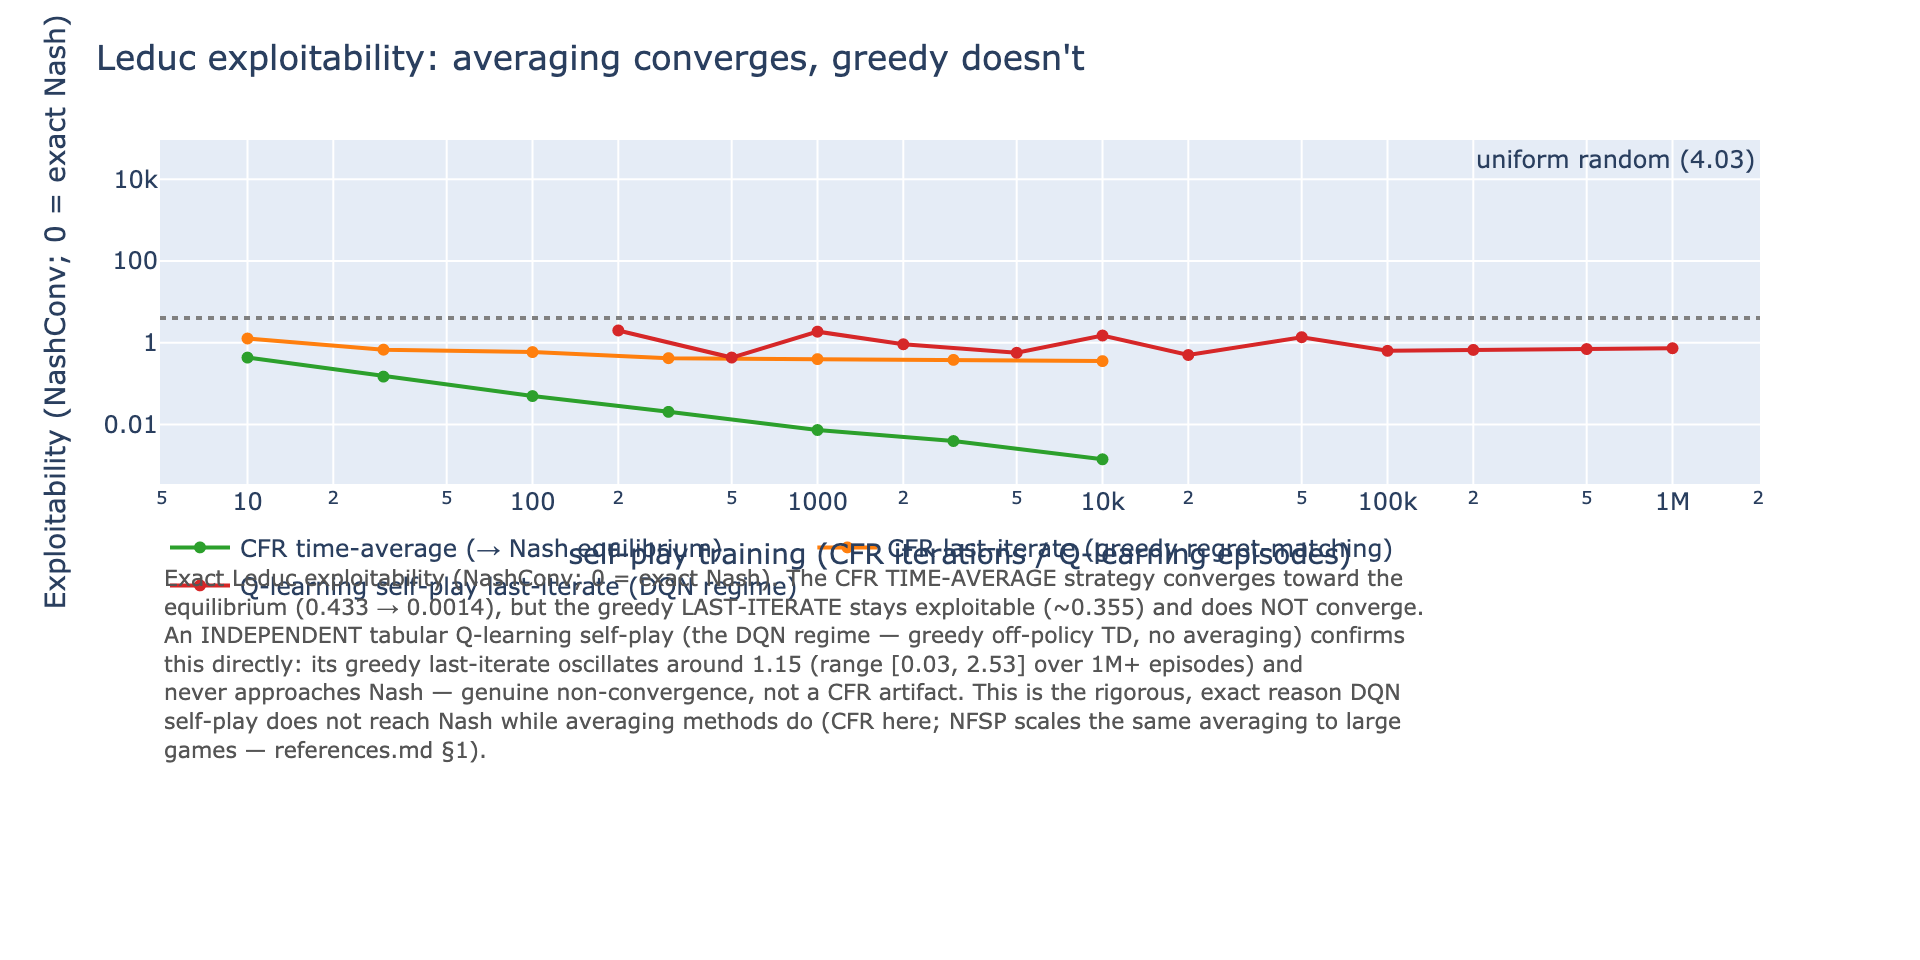

In [3]:
fig("exploitability.png")

## Live check: the metric, recomputed on a known strategy

To show the metric itself is real (not a stored number), compute the exploitability of the uniform-random strategy directly — it should match the committed `uniform_exploitability` above.

In [4]:
from src.leduc_eval import exploitability_of, uniform_strategy_table
live = exploitability_of(uniform_strategy_table())
print(f"live uniform exploitability = {live:.4f}")
print(f"committed                   = {e.get('uniform_exploitability')}")

live uniform exploitability = 4.7470
committed                   = 4.747


### Takeaway

Averaging methods reach Nash; greedy last-iterate self-play does not — shown both by CFR's own last-iterate (~2.2, stays exploitable) and, **directly**, by an independent tabular Q-learner that oscillates around 3.40 (range [1.70, 5.53] over 1M+ episodes) and never reaches Nash. This is the precise, verifiable reason DQN self-play here is a *deliberate baseline*, not a Nash solver. The theoretically grounded next step is **NFSP** (Heinrich & Silver 2016), which carries this averaging to large games via a neural average-policy network (`REFERENCES.md` §1).

*(Corrected, independently-verified numbers: an earlier sign error in the CFR round-transition made the average converge to a degenerate all-call strategy, and a lock-out in the best-response metric underestimated exploitability — even returning impossible negative values for the game value; both were caught while baselining NFSP, confirmed by three independent reimplementations agreeing to machine precision plus a four-way adversarial check, and fixed. The time-average now falls from 0.695 to 0.009 toward Nash; the greedy last-iterate stays exploitable around 2.2; the Q-learner oscillates around 3.40 (range [1.70, 5.53]); the corrected game value ≈ −0.0862 matches the ~−0.0856 known for Leduc. The qualitative result — averaging reaches Nash, greedy value-learning does not — is unchanged.)*